In [ ]:
'''1.Can we use Bagging for regression problems?
Yes
Bagging can be used for both classification and regression.
Example: Random Forest can work as both classifier and regressor.'''

In [ ]:
'''2.What is the difference between multiple model training and single model training?
 Single Model Training      | Multiple Model Training (Ensemble)
 -------------------------- | ----------------------------------
 Uses one model             | Uses multiple models
 Example: One Decision Tree | Example: Random Forest
 High risk of overfitting   | Reduces overfitting
 Less computational cost    | More computational cost.'''

In [ ]:
'''3.Explain the concept of feature randomness in Random Forest?
In Random Forest, not all features are considered at every split.
Instead, a random subset of features is selected for each split.
 This increases diversity among trees and reduces correlation.'''

In [ ]:
'''4.What is OOB (Out-of-Bag) Score?
In Bagging, some samples are not selected during bootstrap sampling. These are called Out-of-Bag samples.
OOB Score:
Used as validation data
Gives an internal performance estimate
No need for separate test set.'''

In [ ]:
'''5.How can you measure the importance of features in a Random Forest models?
Feature importance can be measured by:
Gini Importance (Mean Decrease in Impurity)
Permutation Importance
Checking .feature_importances_ attribute (in sklearn).'''

In [ ]:
'''6.Explain the working principle of a Bagging Classifier
Working principle of a Bagging Classifier
Create multiple bootstrap samples
Train a base model (like Decision Tree) on each sample
Combine predictions using:
Majority voting (classification).'''

In [ ]:
'''7.How do you evaluate a Bagging Classifier’s performance?
Use:
Accuracy
Precision
Recall
F1-score
Confusion Matrix
ROC-AUC score.'''

In [ ]:
'''8.How does a Bagging Regressor work?
Same as Bagging classifier but:
Final output = Average of predictions
Used for regression problems.'''

In [ ]:
'''9.What is the main advantage of ensemble techniques?
Higher accuracy
 Reduced variance
Better generalization.'''

In [ ]:
'''10.What is the main challenge of ensemble methods?
 High computational cost
 Hard to interpret
 More memory usage.'''

In [ ]:
'''11.Explain the key idea behind ensemble techniques?
Combine multiple weak learners to create a strong learner.'''

In [ ]:
'''12.What is a Random Forest Classifier?
Random Forest Classifier:
Collection of multiple decision trees
Uses Bagging + Feature randomness
Final prediction by majority voting.'''

In [ ]:
'''13.What are the main types of ensemble techniques?
Bagging
Boosting
Stacking.'''

In [ ]:
'''14.What is ensemble learning in machine learning?
Ensemble learning is a technique where multiple models are combined to improve overall performance.'''

In [ ]:
'''15.When should we avoid using ensemble methods?
Small datasets
When model interpretability is very important
Limited computational resources.'''

In [ ]:
'''16.How does Bagging help in reducing overfitting?
Uses bootstrap sampling
Reduces variance
Averages multiple models
Prevents model from depending on one dataset.'''

In [ ]:
'''17.Why is Random Forest better than a single Decision Tree?
Reduces overfitting
More stable
Higher accuracy
Handles large datasets better.'''

In [ ]:
'''18.What is the role of bootstrap sampling in Bagging?
Bootstrap sampling:
Creates multiple datasets with replacement
Introduces diversity
Helps reduce variance.'''

In [ ]:
'''19.What are some real-world applications of ensemble techniques?
Medical diagnosis
Fraud detection
Stock price prediction
Spam detection
Credit risk analysis.'''

In [ ]:
'''20.What is the difference between Bagging and Boosting?
 Bagging                      | Boosting
 ---------------------------- | --------------------------------------
 Models trained independently | Models trained sequentially
 Reduces variance             | Reduces bias
 Example: Random Forest       | Example: AdaBoost
 Equal weight to models       | Higher weight to misclassified samples.'''

***Practicals****  


In [ ]:
'''1.Train a Bagging Classifier using Decision Trees on a sample dataset and print model accuracy
# Install (if needed - usually preinstalled in Colab)
!pip install scikit-learn -q

# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# Base model
dt = DecisionTreeClassifier(random_state=42)

# Bagging Classifier
bag_clf = BaggingClassifier(
    estimator=dt,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train
bag_clf.fit(X_train, y_train)

# Predict
y_pred = bag_clf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Bagging Classifier Accuracy:", round(accuracy, 4))

Bagging Classifier Accuracy: 0.9591


In [ ]:
'''2.Train a Bagging Regressor using Decision Trees and evaluate using Mean Squared Error (MSE).
# Install scikit-learn if needed (Colab usually has it)
!pip install scikit-learn -q

# Import libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error

# Load dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create base Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)

# Create Bagging Regressor
bag_reg = BaggingRegressor(
    estimator=dt,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
bag_reg.fit(X_train, y_train)

# Make predictions
y_pred = bag_reg.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", round(mse, 4))

Mean Squared Error (MSE): 0.2568


In [ ]:
'''3.Train a Random Forest Classifier on the Breast Cancer dataset and print feature importance scores
# Install if needed (already available in Colab usually)
!pip install scikit-learn -q

# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

# Get feature importance
importance = rf.feature_importances_

# Create DataFrame for better display
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance Score': importance
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by='Importance Score', ascending=False
)

print(feature_importance_df)

                    Feature  Importance Score
7       mean concave points          0.141934
27     worst concave points          0.127136
23               worst area          0.118217
6            mean concavity          0.080557
20             worst radius          0.077975
22          worst perimeter          0.074292
2            mean perimeter          0.060092
3                 mean area          0.053810
26          worst concavity          0.041080
0               mean radius          0.032312
13               area error          0.029538
21            worst texture          0.018786
25        worst compactness          0.017539
10             radius error          0.016435
28           worst symmetry          0.012929
12          perimeter error          0.011770
24         worst smoothness          0.011769
1              mean texture          0.011064
5          mean compactness          0.009216
19  fractal dimension error          0.007135
29  worst fractal dimension       

In [6]:
# 4.Train a Random Forest Regressor and compare its performance with a single Decision Tree
# Import libraries
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Load dataset
data = load_diabetes()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# 1. Decision Tree Regressor
# -----------------------------
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_r2 = r2_score(y_test, y_pred_dt)

# -----------------------------
# 2. Random Forest Regressor
# -----------------------------
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

# Print results
print("Decision Tree Regressor Performance:")
print("MSE:", dt_mse)
print("R2 Score:", dt_r2)

print("\nRandom Forest Regressor Performance:")
print("MSE:", rf_mse)
print("R2 Score:", rf_r2)

Decision Tree Regressor Performance:
MSE: 5697.789473684211
R2 Score: -0.05547696148647652

Random Forest Regressor Performance:
MSE: 2859.641982706767
R2 Score: 0.47027066465218703


In [ ]:
'''5. Compute the Out-of-Bag (OOB) Score for a Random Forest Classifier
# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset (OOB score uses out-of-bag samples from training data itself,
# but splitting is good practice for overall model evaluation if needed later)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Random Forest model with oob_score=True
rf_oob = RandomForestClassifier(
    n_estimators=100,
    oob_score=True, # Enable OOB score calculation
    random_state=42,
    n_jobs=-1 # Use all available cores
)

rf_oob.fit(X_train, y_train)

# Get OOB score
oob_score = rf_oob.oob_score_

print("Random Forest OOB Score:", round(oob_score, 4))

Random Forest OOB Score: 0.9548


In [7]:
'''6.Train a Bagging Classifier using SVM as a base estimator and print accuracy
# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create SVM base estimator
svm = SVC(kernel='linear', probability=True, random_state=42)

# Create Bagging Classifier with SVM
bagging_model = BaggingClassifier(
    estimator=svm,
    n_estimators=10,
    random_state=42
)

# Train model
bagging_model.fit(X_train, y_train)

# Predict
y_pred = bagging_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Bagging Classifier (SVM base) Accuracy:", accuracy)

Bagging Classifier (SVM base) Accuracy: 0.9649122807017544


In [9]:
'''7.Train a Random Forest Classifier with different numbers of trees and compare accuracy
# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Different numbers of trees
tree_counts = [10, 50, 100, 200]

print("Random Forest Accuracy Comparison:\n")

for n in tree_counts:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Number of Trees: {n}  |  Accuracy: {accuracy:.4f}")

Random Forest Accuracy Comparison:

Number of Trees: 10  |  Accuracy: 0.9649
Number of Trees: 50  |  Accuracy: 0.9708
Number of Trees: 100  |  Accuracy: 0.9708
Number of Trees: 200  |  Accuracy: 0.9708


In [11]:
'''8.Train a Bagging Classifier using Logistic Regression as a base estimator and print AUC score
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Logistic Regression base model
log_reg = LogisticRegression(max_iter=5000)

# Bagging with Logistic Regression
bagging_model = BaggingClassifier(
    estimator=log_reg,
    n_estimators=10,
    random_state=42
)

# Train model
bagging_model.fit(X_train, y_train)

# Predict probabilities
y_proba = bagging_model.predict_proba(X_test)[:, 1]

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_proba)

print("Bagging (Logistic Regression base) AUC Score:", round(auc_score, 4))

Bagging (Logistic Regression base) AUC Score: 0.9974


In [14]:
'''9.Train a Random Forest Regressor and analyze feature importance scores
# Import libraries
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Load dataset
data = load_diabetes()
X = data.data
y = data.target
feature_names = data.feature_names

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Model evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Feature importance
importance = rf.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

# Print results
print("Model Performance:")
print("MSE:", round(mse, 2))
print("R2 Score:", round(r2, 4))

print("\nFeature Importance Scores:\n")
print(feature_importance_df)

Model Performance:
MSE: 2859.64
R2 Score: 0.4703

Feature Importance Scores:

  Feature  Importance
2     bmi    0.400000
8      s5    0.166602
3      bp    0.104839
9      s6    0.071358
6      s3    0.061730
0     age    0.058633
4      s1    0.049191
5      s2    0.047138
7      s4    0.029427
1     sex    0.011082


In [18]:
'''10.Train an ensemble model using both Bagging and Random Forest and compare accuracy
# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# 1️⃣ Bagging Classifier
# -----------------------------
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)
bagging_accuracy = accuracy_score(y_test, y_pred_bag)

# -----------------------------
# 2️⃣ Random Forest Classifier
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

# Print results
print("Bagging Classifier Accuracy:", round(bagging_accuracy, 4))
print("Random Forest Accuracy:", round(rf_accuracy, 4))

Bagging Classifier Accuracy: 0.9591
Random Forest Accuracy: 0.9708


In [20]:
 '''11.Train a Random Forest Classifier and tune hyperparameters using GridSearchCV
# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Define model
rf = RandomForestClassifier(random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train model
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print results
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", round(grid_search.best_score_, 4))
print("Test Accuracy:", round(accuracy, 4))

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Score: 0.9572
Test Accuracy: 0.9708


In [22]:
'''12.Train a Bagging Regressor with different numbers of base estimators and compare performance
# Import libraries
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
data = load_diabetes()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Different numbers of base estimators
estimators_list = [1, 10, 50, 100, 200]

print("Bagging Regressor Performance Comparison:\n")

for n in estimators_list:
    model = BaggingRegressor(
        estimator=DecisionTreeRegressor(),
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Number of Estimators: {n}")
    print(f"MSE: {mse:.2f}")
    print(f"R2 Score: {r2:.4f}")
    print("-" * 40)

Bagging Regressor Performance Comparison:

Number of Estimators: 1
MSE: 5545.98
R2 Score: -0.0274
----------------------------------------
Number of Estimators: 10
MSE: 3237.53
R2 Score: 0.4003
----------------------------------------
Number of Estimators: 50
MSE: 2987.01
R2 Score: 0.4467
----------------------------------------
Number of Estimators: 100
MSE: 2908.81
R2 Score: 0.4612
----------------------------------------
Number of Estimators: 200
MSE: 2854.88
R2 Score: 0.4712
----------------------------------------


In [24]:
'''13.Train a Random Forest Classifier and analyze misclassified samples
# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd
import numpy as np

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Find misclassified samples
misclassified_indices = np.where(y_test != y_pred)[0]
print("\nNumber of Misclassified Samples:", len(misclassified_indices))

# Show first 5 misclassified samples
print("\nFirst 5 Misclassified Samples:\n")

for i in misclassified_indices[:5]:
    print(f"Index: {i}")
    print("Actual Label:", y_test[i])
    print("Predicted Label:", y_pred[i])
    print("-" * 40)

Model Accuracy: 0.9708

Confusion Matrix:
 [[ 59   4]
 [  1 107]]

Number of Misclassified Samples: 5

First 5 Misclassified Samples:

Index: 8
Actual Label: 1
Predicted Label: 0
----------------------------------------
Index: 20
Actual Label: 0
Predicted Label: 1
----------------------------------------
Index: 77
Actual Label: 0
Predicted Label: 1
----------------------------------------
Index: 82
Actual Label: 0
Predicted Label: 1
----------------------------------------
Index: 164
Actual Label: 0
Predicted Label: 1
----------------------------------------


In [26]:
'''14.Train a Bagging Classifier and compare its performance with a single Decision Tree Classifier
# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# 1️⃣ Single Decision Tree
# -----------------------------
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

# -----------------------------
# 2️⃣ Bagging Classifier
# -----------------------------
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)
bagging_accuracy = accuracy_score(y_test, y_pred_bag)

# Print results
print("Decision Tree Accuracy:", round(dt_accuracy, 4))
print("Bagging Classifier Accuracy:", round(bagging_accuracy, 4))

Decision Tree Accuracy: 0.9415
Bagging Classifier Accuracy: 0.9591


Model Accuracy: 0.9708


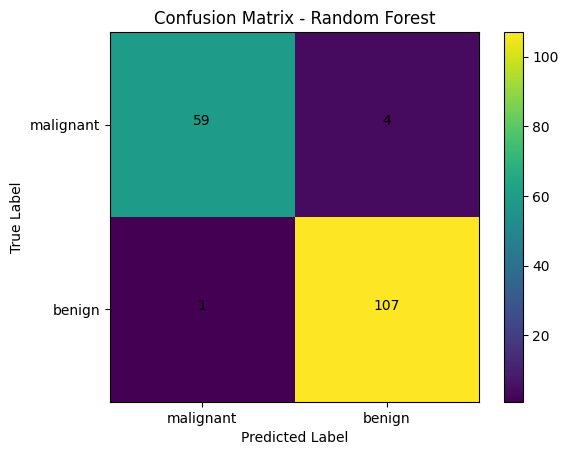

In [28]:
'''15.Train a Random Forest Classifier and visualize the confusion matrix
# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - Random Forest")
plt.colorbar()

classes = data.target_names
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Annotate matrix values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center")

plt.show()

In [30]:
'''16.Train a Stacking Classifier using Decision Trees, SVM, and Logistic Regression, and compare accuracy
# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Base models
dt = DecisionTreeClassifier(random_state=42)
svm = SVC(kernel='linear', probability=True, random_state=42)
lr = LogisticRegression(max_iter=5000)

# Train individual models
dt.fit(X_train, y_train)
svm.fit(X_train, y_train)
lr.fit(X_train, y_train)

# Predictions
dt_acc = accuracy_score(y_test, dt.predict(X_test))
svm_acc = accuracy_score(y_test, svm.predict(X_test))
lr_acc = accuracy_score(y_test, lr.predict(X_test))

# Stacking Classifier
estimators = [
    ('dt', dt),
    ('svm', svm),
    ('lr', lr)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

stack_model.fit(X_train, y_train)
stack_acc = accuracy_score(y_test, stack_model.predict(X_test))

# Print results
print("Decision Tree Accuracy:", round(dt_acc, 4))
print("SVM Accuracy:", round(svm_acc, 4))
print("Logistic Regression Accuracy:", round(lr_acc, 4))
print("Stacking Classifier Accuracy:", round(stack_acc, 4))

Decision Tree Accuracy: 0.9415
SVM Accuracy: 0.9649
Logistic Regression Accuracy: 0.9766
Stacking Classifier Accuracy: 0.9766


In [32]:
'''17.Train a Random Forest Classifier and print the top 5 most important features
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature importance
importance = rf.feature_importances_

feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("Top 5 Important Features:\n")
print(feature_df.head(5))

Top 5 Important Features:

                 Feature  Importance
7    mean concave points    0.141934
27  worst concave points    0.127136
23            worst area    0.118217
6         mean concavity    0.080557
20          worst radius    0.077975


In [34]:
'''18.Train a Bagging Classifier and evaluate performance using Precision, Recall, and F1-score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Bagging model
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)
y_pred = bagging.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



In [36]:
'''19.Train a Random Forest Classifier and analyze the effect of max_depth on accuracy
from sklearn.metrics import accuracy_score

depths = [None, 5, 10, 15, 20]

print("Effect of max_depth on Accuracy:\n")

for depth in depths:
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"max_depth = {depth} | Accuracy = {acc:.4f}")

Effect of max_depth on Accuracy:

max_depth = None | Accuracy = 0.9708
max_depth = 5 | Accuracy = 0.9649
max_depth = 10 | Accuracy = 0.9708
max_depth = 15 | Accuracy = 0.9708
max_depth = 20 | Accuracy = 0.9708


In [38]:
'''20.Train a Bagging Regressor using different base estimators (DecisionTree and KNeighbors) and compare
# performance
# Import libraries
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
data = load_diabetes()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# 1️⃣ Bagging with Decision Tree
# -----------------------------
bag_dt = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    random_state=42
)

bag_dt.fit(X_train, y_train)
y_pred_dt = bag_dt.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

# -----------------------------
# 2️⃣ Bagging with KNN
# -----------------------------
bag_knn = BaggingRegressor(
    estimator=KNeighborsRegressor(),
    n_estimators=100,
    random_state=42
)

bag_knn.fit(X_train, y_train)
y_pred_knn = bag_knn.predict(X_test)

mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

# Print results
print("Bagging with Decision Tree:")
print("MSE:", round(mse_dt, 2))
print("R2 Score:", round(r2_dt, 4))

print("\nBagging with KNN:")
print("MSE:", round(mse_knn, 2))
print("R2 Score:", round(r2_knn, 4))

Bagging with Decision Tree:
MSE: 2908.81
R2 Score: 0.4612

Bagging with KNN:
MSE: 3188.74
R2 Score: 0.4093


ROC-AUC Score: 0.9968


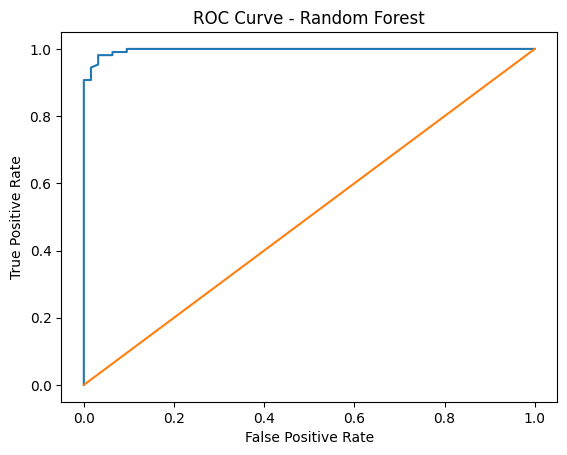

In [40]:
'''21.Train a Random Forest Classifier and evaluate its performance using ROC-AUC Score
# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict probabilities
y_proba = rf.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
auc_score = roc_auc_score(y_test, y_proba)

print("ROC-AUC Score:", round(auc_score, 4))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.show()

In [43]:
 '''22.Train a Bagging Classifier and evaluate its performance using cross-validation
# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Create Bagging model
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

# Perform 5-fold Cross Validation
cv_scores = cross_val_score(bagging, X, y, cv=5, scoring='accuracy')

# Print results
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean Accuracy:", round(np.mean(cv_scores), 4))
print("Standard Deviation:", round(np.std(cv_scores), 4))

Cross-Validation Accuracy Scores: [0.89473684 0.93859649 0.99122807 0.96491228 1.        ]
Mean Accuracy: 0.9579
Standard Deviation: 0.0382


Average Precision (AP) Score: 0.9981


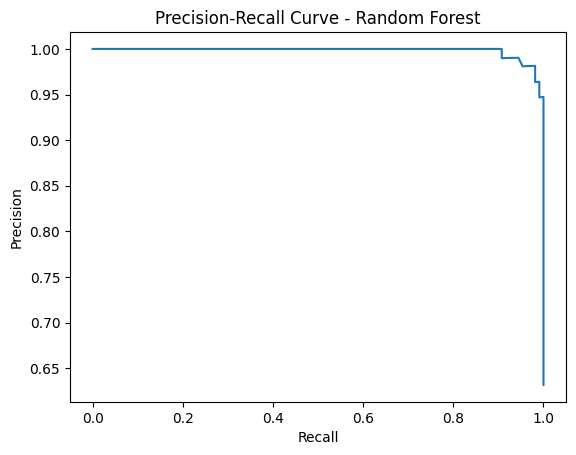

In [45]:
'''23.Train a Random Forest Classifier and plot the Precision-Recall curve
# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict probabilities
y_proba = rf.predict_proba(X_test)[:, 1]

# Compute Precision-Recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Compute Average Precision score
ap_score = average_precision_score(y_test, y_proba)

print("Average Precision (AP) Score:", round(ap_score, 4))

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.show()

In [47]:
# 24.Train a Stacking Classifier with Random Forest and Logistic Regression and compare accuracy
# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Base models
rf = RandomForestClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression(max_iter=5000)

# Train individual models
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

rf_acc = accuracy_score(y_test, rf.predict(X_test))
lr_acc = accuracy_score(y_test, lr.predict(X_test))

# Stacking model
estimators = [
    ('rf', rf),
    ('lr', lr)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

stack_model.fit(X_train, y_train)
stack_acc = accuracy_score(y_test, stack_model.predict(X_test))

# Print results
print("Random Forest Accuracy:", round(rf_acc, 4))
print("Logistic Regression Accuracy:", round(lr_acc, 4))
print("Stacking Classifier Accuracy:", round(stack_acc, 4))

Random Forest Accuracy: 0.9708
Logistic Regression Accuracy: 0.9766
Stacking Classifier Accuracy: 0.9708


In [49]:
# 25.Train a Bagging Regressor with different levels of bootstrap samples and compare performance
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
data = load_diabetes()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Different bootstrap sample fractions
sample_sizes = [0.5, 0.7, 1.0]

print("Bagging Regressor Performance with Different Bootstrap Sample Sizes:\n")

for size in sample_sizes:
    model = BaggingRegressor(
        estimator=DecisionTreeRegressor(),
        n_estimators=100,
        max_samples=size,
        bootstrap=True,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Max Samples: {size}")
    print(f"MSE: {mse:.2f}")
    print(f"R2 Score: {r2:.4f}")
    print("-" * 40)

Bagging Regressor Performance with Different Bootstrap Sample Sizes:

Max Samples: 0.5
MSE: 2748.31
R2 Score: 0.4909
----------------------------------------
Max Samples: 0.7
MSE: 2768.27
R2 Score: 0.4872
----------------------------------------
Max Samples: 1.0
MSE: 2908.81
R2 Score: 0.4612
----------------------------------------
